# Important Libraries

In [3]:
!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.layers import Layer
import tensorflow as tf

# Download Stock Data TSLA


In [4]:
# Download Tesla stock data
data = yf.download("TSLA", start="2015-01-01", end="2024-01-01")

# Keep only Close price
data = data[['Close']]

# Show dataset shape and first 5 rows
print("Dataset Shape:", data.shape)
data.head()

/tmp/ipython-input-1246/4149760094.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("TSLA", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Dataset Shape: (2264, 1)


Price,Close
Ticker,TSLA
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


# Plot Closing point

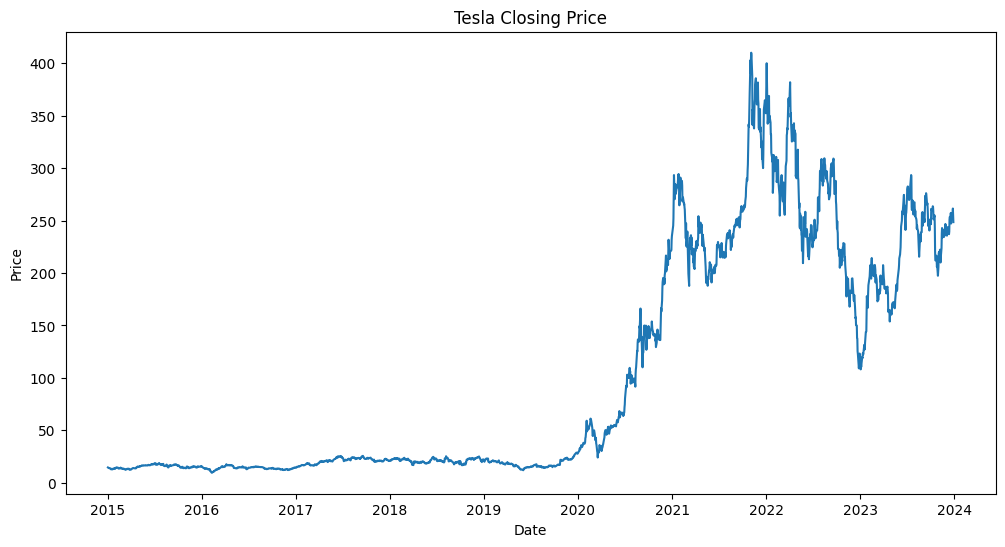

In [5]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# Preprocessing Normalize data

In [6]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print("First 5 normalized values:")
print(scaled_data[:5])

First 5 normalized values:
[[0.01259433]
 [0.01105916]
 [0.0112573 ]
 [0.01120235]
 [0.01114741]]


In [7]:
def create_sequences(data, window_size=10):
    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

window_size = 10
X, y = create_sequences(scaled_data, window_size)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (2254, 10, 1)
Output shape: (2254, 1)


# Show 3 input-output Example

In [8]:
for i in range(3):
    print("Input:", X[i].flatten())
    print("Output:", y[i])
    print("------")

Input: [0.01259433 0.01105916 0.0112573  0.01120235 0.01114741 0.01048805
 0.00974712 0.01008678 0.008162   0.00802547]
Output: [0.00822527]
------
Input: [0.01105916 0.0112573  0.01120235 0.01114741 0.01048805 0.00974712
 0.01008678 0.008162   0.00802547 0.00822527]
Output: [0.00803546]
------
Input: [0.0112573  0.01120235 0.01114741 0.01048805 0.00974712 0.01008678
 0.008162   0.00802547 0.00822527 0.00803546]
Output: [0.00880803]
------


# Test Train Split

In [9]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1803, 10, 1)
Testing samples: (451, 10, 1)


# Build RNN Model

In [10]:
rnn_model = Sequential([
    SimpleRNN(64, input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

# Train RNN

In [11]:
start_time = time.time()

rnn_history = rnn_model.fit(X_train, y_train, epochs=10, batch_size=32)

rnn_training_time = time.time() - start_time
print("RNN Training Time:", rnn_training_time)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0077
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.7093e-04
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4599e-04
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6212e-04
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7390e-04
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3428e-04
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4223e-04
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7363e-04
Epoch 9/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5376e-04
Epoch 10/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6955e-04
RNN Training Time: 4.957860946655273


# Plot Traning Loss

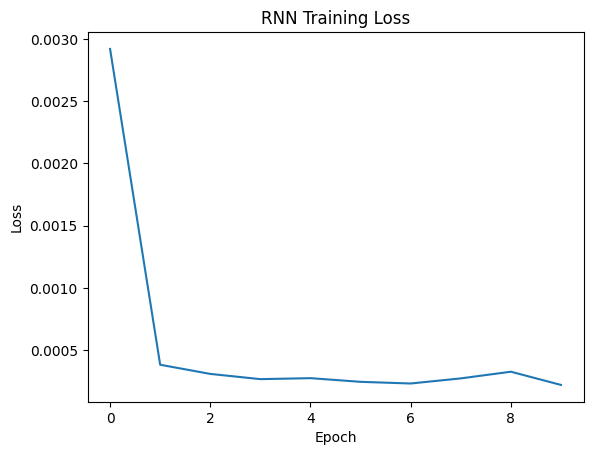

In [12]:
plt.plot(rnn_history.history['loss'])
plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Evaluate RNN

In [13]:
rnn_pred = rnn_model.predict(X_test)

rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_pred))
rnn_mae = mean_absolute_error(y_test, rnn_pred)

print("RNN RMSE:", rnn_rmse)
print("RNN MAE:", rnn_mae)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
RNN RMSE: 0.0253340284470921
RNN MAE: 0.019752459650211253


# Build LSTM Model

In [14]:
lstm_model = Sequential([
    LSTM(64, input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

# Train LSTM

In [15]:
start_time = time.time()

lstm_history = lstm_model.fit(X_train, y_train, epochs=10, batch_size=32)

lstm_training_time = time.time() - start_time
print("LSTM Training Time:", lstm_training_time)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0306
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0047e-04
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.5259e-04
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8201e-04
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.5735e-04
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6066e-04
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8390e-04
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1349e-04
Epoch 9/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.7082e-04
Epoch 10/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.5674e-04
LSTM Training Time: 8.20611310005188


# Evaluate LSTM

In [16]:
lstm_pred = lstm_model.predict(X_test)

lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
lstm_mae = mean_absolute_error(y_test, lstm_pred)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE:", lstm_mae)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
LSTM RMSE: 0.041431868312798215
LSTM MAE: 0.03277522147301245


# Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "RMSE": [rnn_rmse, lstm_rmse],
    "MAE": [rnn_mae, lstm_mae],
    "Training Time": [rnn_training_time, lstm_training_time]
})

comparison

,Model,RMSE,MAE,Training Time
0,RNN,0.025334,0.019752,4.957861
1,LSTM,0.041432,0.032775,8.206113


# Custom Attention Layer

In [18]:
class Attention(Layer):
    def call(self, inputs):
        score = tf.nn.tanh(inputs)
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector

# LSTM + Attention Model

In [19]:
inputs = tf.keras.Input(shape=(window_size,1))
lstm_out = LSTM(64, return_sequences=True)(inputs)
attention_out = Attention()(lstm_out)
output = Dense(1)(attention_out)

attention_model = tf.keras.Model(inputs, output)
attention_model.compile(optimizer='adam', loss='mse')

# Train Attention Model

In [20]:
attention_model.fit(X_train, y_train, epochs=10, batch_size=32)

att_pred = attention_model.predict(X_test)

att_rmse = np.sqrt(mean_squared_error(y_test, att_pred))
att_mae = mean_absolute_error(y_test, att_pred)

print("Attention RMSE:", att_rmse)
print("Attention MAE:", att_mae)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0219
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.9869e-04
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.4844e-04
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.4735e-04
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.3333e-04
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6206e-04
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.5585e-04
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9299e-04
Epoch 9/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.7092e-04
Epoch 10/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.0895e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Attention RMSE: 0.05795945039614435
Attention MAE: 0.04533493445031444
